In [1]:
library(bsseq)
library(SummarizedExperiment)
library(GenomicRanges)
library(matrixStats)
library(ggplot2)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loa

In [2]:
group_colors <- c(
  'LOY' = '#0000C0',
  'ROY' = '#ED7D31'
)

label_map <- c(
  'D11' = 'LOY 1',
  'E5B' = 'LOY 2',
  'E6B' = 'LOY 3',
  'F10' = 'LOY 4',
  'A3'  = 'ROY 1',
  'C1'  = 'ROY 2',
  'C8'  = 'ROY 3',
  'D5'  = 'ROY 4'
)

In [3]:
bs_obj <- readRDS(
  'data/bsseq_obj_corrected_v2.rds' #bsseq object can be provided upon reque
)

pheno <- data.frame(
  Sample    = c('A3', 'C1', 'C8', 'D5', 'D11', 'E5B', 'E6B', 'F10'),
  Condition = c('ROY', 'ROY', 'ROY', 'ROY', 'LOY', 'LOY', 'LOY', 'LOY'),
  row.names = c('A3', 'C1', 'C8', 'D5', 'D11', 'E5B', 'E6B', 'F10'),
  stringsAsFactors = FALSE
)
pData(bs_obj) <- pheno

In [4]:
# Subset to autosomal chromosomes only
autosomes <- paste0('chr', 1:22)
bs_auto   <- bs_obj[seqnames(rowRanges(bs_obj)) %in% autosomes, ]

# Coverage filter: keep CpGs with >= 5x coverage in all samples
cov  <- getCoverage(bs_auto, type = 'Cov')
keep <- rowSums(cov >= 5) == ncol(bs_auto)

# Extract beta values and select top 50,000 most variable CpGs
beta_matrix <- getMeth(bs_auto, type = 'raw')[keep, ]
var_cpg     <- rowVars(beta_matrix)
top_idx     <- order(var_cpg, decreasing = TRUE)[seq_len(50000)]
beta_top    <- beta_matrix[top_idx, ]

In [5]:
# PCA
pca_result    <- prcomp(t(beta_top), center = TRUE, scale. = FALSE)
var_explained <- summary(pca_result)$importance[2, 1:2] * 100

pca_data <- data.frame(
  PC1       = pca_result$x[, 1],
  PC2       = pca_result$x[, 2],
  Sample    = rownames(pca_result$x),
  Condition = pData(bs_auto)$Condition,
  stringsAsFactors = FALSE
)
pca_data$Label <- label_map[pca_data$Sample]

# Separate overlapping ROY 2 (C1) and ROY 4 (D5) points for visibility
pca_data$PC1_plot <- pca_data$PC1
pca_data$PC2_plot <- pca_data$PC2

pca_data$PC1_plot[pca_data$Label == 'ROY 2'] <- pca_data$PC1[pca_data$Label == 'ROY 2'] - 2.0
pca_data$PC2_plot[pca_data$Label == 'ROY 2'] <- pca_data$PC2[pca_data$Label == 'ROY 2'] + 1.5
pca_data$PC1_plot[pca_data$Label == 'ROY 4'] <- pca_data$PC1[pca_data$Label == 'ROY 4'] + 2.0
pca_data$PC2_plot[pca_data$Label == 'ROY 4'] <- pca_data$PC2[pca_data$Label == 'ROY 4'] - 1.5

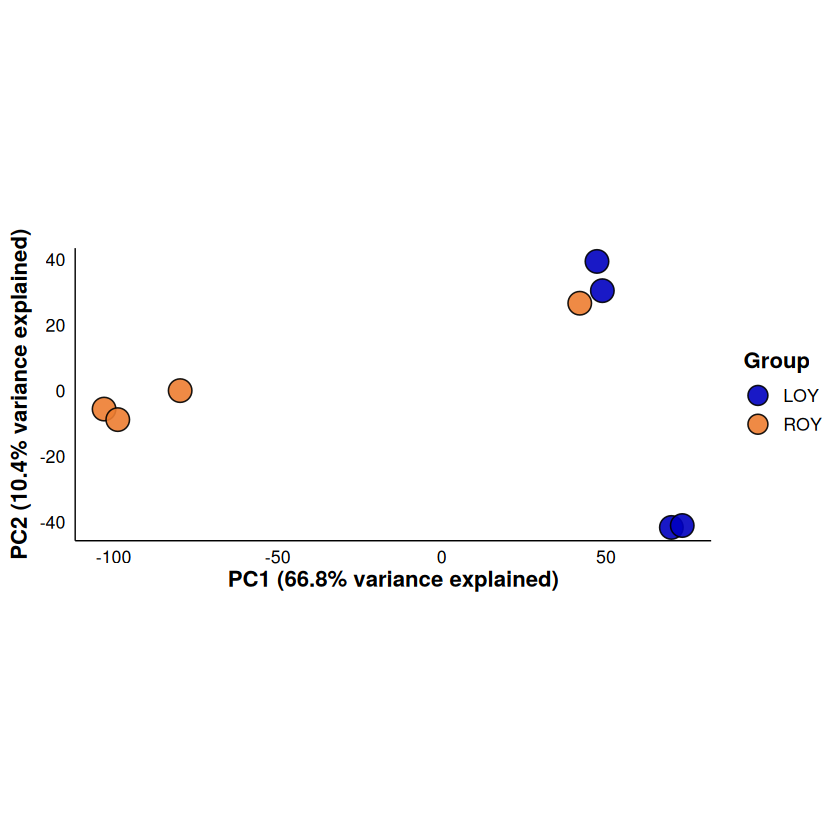

In [6]:
p <- ggplot(pca_data, aes(x = PC1_plot, y = PC2_plot)) +
  geom_point(
    aes(fill = Condition),
    shape  = 21,
    size   = 6,
    alpha  = 0.9,
    color  = 'black',
    stroke = 0.5
  ) +
  scale_fill_manual(
    values = group_colors,
    guide  = guide_legend(override.aes = list(size = 5, shape = 21))
  ) +
  labs(
    x    = sprintf('PC1 (%.1f%% variance explained)', var_explained[1]),
    y    = sprintf('PC2 (%.1f%% variance explained)', var_explained[2]),
    fill = 'Group'
  ) +
  coord_equal() +
  theme_minimal(base_size = 13) +
  theme(
    axis.title        = element_text(face = 'bold'),
    axis.text         = element_text(color = 'black'),
    panel.grid.major  = element_blank(),
    panel.grid.minor  = element_blank(),
    axis.line         = element_line(color = 'black', linewidth = 0.3),
    axis.line.x.top   = element_blank(),
    axis.line.y.right = element_blank(),
    legend.title      = element_text(face = 'bold'),
    legend.key        = element_blank()
  )
p